In [23]:
#Imports necessarios para o funcionamento do modelo
import torch
import torch.nn as nn
import torch
from torchvision import transforms
from PIL import Image
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import transforms
import requests
import os

In [24]:
#Utilizar GPU se tiver disponivel
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
#Mostrar se é CPU ou CUDA
device

device(type='cpu')

In [ ]:
# --- Baixar MODELO ---
MODEL_DIR = 'Modelos'
MODEL_FILE = 'epoca_183_best_model_acc_69.70_loss_1.0901.pth'
MODEL_URL = f"https://raw.githubusercontent.com/Alewahl12/TrabalhoVisCompA1/main/Modelos/{MODEL_FILE}"

# Cria a pasta Modelos se não existir
if not os.path.exists(MODEL_DIR):
    os.makedirs(MODEL_DIR)

model_path = os.path.join(MODEL_DIR, MODEL_FILE)

# Se o modelo não existir localmente, baixa o arquivo
if not os.path.isfile(model_path):
    print("Baixando o modelo...")
    response = requests.get(MODEL_URL)
    if response.status_code == 200:
        with open(model_path, 'wb') as f:
            f.write(response.content)
        print("Modelo baixado com sucesso!")
    else:
        raise Exception("Erro ao baixar o modelo.")

Baixando o modelo...
Modelo baixado com sucesso!


In [ ]:
# --- Baixar as imagens de inferência ---
imagens_dir = 'imagens_inferencia'
if not os.path.exists(imagens_dir):
    os.makedirs(imagens_dir)

url_api = "https://api.github.com/repos/Alewahl12/TrabalhoVisCompA1/contents/imagens_inferencia"
response = requests.get(url_api)
if response.status_code == 200:
    images_info = response.json()
else:
    raise Exception("Erro ao acessar a API do GitHub para imagens")

downloaded_images_paths = []
for item in images_info:
    if item['type'] == 'file':
        filename = item['name']
        raw_url = item['download_url']
        local_path = os.path.join(imagens_dir, filename)
        if not os.path.isfile(local_path):
            img_response = requests.get(raw_url)
            if img_response.status_code == 200:
                with open(local_path, 'wb') as f:
                    f.write(img_response.content)
                print(f"Imagem {filename} baixada com sucesso!")
            else:
                print(f"Falha ao baixar {filename}")
        downloaded_images_paths.append(local_path)

# Carrega as imagens em uma lista
imagens_list = []
for img_path in downloaded_images_paths:
    try:
        img = Image.open(img_path)
        imagens_list.append(img)
    except Exception as e:
        print(f"Erro ao abrir imagem {img_path}: {e}")

print(f"Total de imagens carregadas: {len(imagens_list)}")

Imagem borzoi.jpg baixada com sucesso!
Total de imagens carregadas: 1


In [29]:
# Definir a URL com as classes
url_classes = "https://raw.githubusercontent.com/Alewahl12/TrabalhoVisCompA1/refs/heads/main/classes.txt"

# Baixa o conteúdo do arquivo de classes
response = requests.get(url_classes)
if response.status_code == 200:
    classes_list = [linha.strip() for linha in response.text.split('\n') if linha.strip()]
else:
    raise Exception("Erro ao baixar o arquivo de classes.")

# Imprime o número de classes e os nomes das classes
num_classes = len(classes_list)
print("Número de classes:", num_classes)
print("Classes:", classes_list)

Número de classes: 120
Classes: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_

In [30]:
# Transformações necessariar para o modelo classificar
validate_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [31]:
#Modelo CNN para classificar a imagem
class ScratchCNN(nn.Module):
    def __init__(self, num_classes: int):
        super(ScratchCNN, self).__init__()
        self.features = nn.Sequential(
            # Bloco 1: 3 -> 64
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 -> 112

            # Bloco 2: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 -> 56

            # Bloco 3: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 -> 28

            # Bloco 4: 256 -> 512
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14

            # Bloco 5: 512 -> 512
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 14 -> 7

            # Adaptive pooling: 7x7 -> 1x1
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),             # 512 x 1 x 1 -> 512
            nn.Dropout(p=0.5),
            nn.Linear(512, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x
    

In [ ]:
# 5) CARREGA PESOS E PREPARA PARA INFERÊNCIA
model = ScratchCNN(num_classes=num_classes).to(device)
model_path = os.path.join(MODEL_DIR, MODEL_FILE)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint)
model.eval()
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


C:\Users\Felip\AppData\Local\Temp\ipykernel_32144\2176411454.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f"{MODEL_DIR}\\{MODEL_FILE}", map_lo

Classe prevista: n02090622-borzoi
Confiança: 0.99099


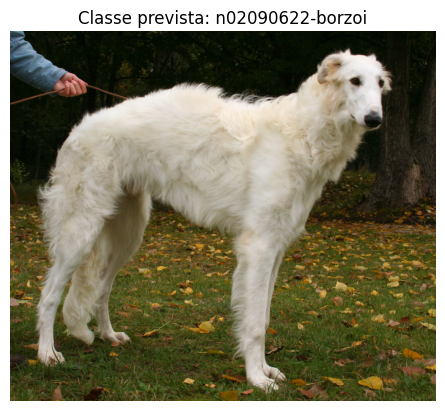

In [34]:
for img in imagens_list:
    # Preprocessa a imagem
    img_tensor = validate_transform(img).unsqueeze(0).to(device)
    
    # Realiza a inferência
    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)
        pred_class = classes_list[pred.item()]
        confidence = torch.nn.functional.softmax(output, dim=1)[0][pred.item()].item()
    
    # Exibe o resultado da inferência
    print("Classe prevista:", pred_class)
    print(f"Confiança: {confidence:.5f}")
    
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Classe prevista: {pred_class}')
    plt.show()